<h1> <a id="title"></a>Differencing and geostatistical error analysis in lidar topographic differencing: Workflow starting with user provided DEMs</h1>

This work was funded by the [John Wesley Powell Center for Analysis and Synthesis (USGS G23AC00336)](https://www.usgs.gov/centers/john-wesley-powell-center-for-analysis-and-synthesis/science/a-national-topographic-change#overview) and [OpenTopography](https://opentopography.org).  OpenTopography is supported by the National Science Foundation under Awards # 2410799, 2410800 & 2410801.

<h2><a id="introduction"></a>1. Introduction</h2>

Vertical topographic differencing calculates net change in the vertical dimension by comparing digital elevation models (DEMs) collected at different times ([Izumida et al., 2017](https://doi.org/10.5194/nhess-17-1505-2017); [Wheaton et al., 2010](https://doi.org/10.1002/esp.1886)). Topographic differencing underpins a wide range of studies, spanning vegetation biomass changes, lava-flow emplacement ([Albino et al., 2015](https://doi.org/10.1002/2015JB011988)), fluvial and coastal floods ([Izumida et al., 2017](https://doi.org/10.5194/nhess-17-1505-2017)), landslides ([Lucieer et al., 2014](https://doi.org/10.1177/0309133313515293)), fine-scale fluvial sediment budgets ([Wheaton et al., 2010](https://doi.org/10.1002/esp.1886)), and tectonic activity ([Langridge et al., 2014](https://doi.org/10.1016/j.geomorph.2014.08.007); [Scott et al., 2018](https://doi.org/10.1029/2018JB015581)).

<h3><a id="differencing_def"></a>Vertical topographic differencing</h3>

Vertical differencing is the pixel-by-pixel subtraction of two digital-elevation models (DEMs) that share a common coordinate system and identical grid geometry (e.g., [Scott et al., 2021](https://doi.org/10.1130/GES02259.1)). Because every cell occupies the same planimetric position in both rasters, subtracting them yields a raster of elevation change ($\Delta z$). Researchers rarely inspect the differencing value of every cell individually. Instead, aggregate change is summarized over a specific feature or landform (net sediment deposition on a bar, net tree growth in a reforested stand, net inflation along a volcanic flank, etc.) The mean elevation change over a polygon $\Omega$ is:

$$\Delta z^{aggregate} = \frac{1}{N} \sum_{i=1}^{N} \Delta z_i$$

where the sum of $i$ individual topographic change measurements ($\Delta z_i$) is taken over the $N$ cells that fall inside $\Omega$.

<h3><a id="uncertainty_matters"></a>Why uncertainty matters</h3> 

The elevation change observed in a differenced raster can be decomposed as:

$$\Delta_{z}^{measured} = \Delta_{z}^{actual} + \Delta_{z}^{error}$$

where:
- **Δz<sub>actual</sub>** is the true vertical change (erosion, deposition, uplift, subsidence, construction, vegetation change, etc.)
- **Δz<sub>error</sub>** is the cumulative vertical error from data collection, processing, and alignment (GNSS/INS errors, boresight errors, DEM interpolation artifacts, alignment errors, metadata errors)

Errors present in either dataset are often of similar magnitude to the true change, particularly for legacy datasets acquired with less advanced instrumentation, lower point density, or incomplete metadata ([Glennie et al., 2014](https://doi.org/10.1002/2014GL059919)).


<h3><a id="error_types"></a>Error types in lidar topographic differencing</h3>

<h4><a id="short_scale"></a>Short-scale errors (meters to tens of meters)</h4>

| Error Type | Description | Key References |
|------------|-------------|----------------|
| **Random noise** | Sensor sensitivity, environmental conditions, and GNSS/IMU interference produce scattered positive/negative differences | [Glennie, 2007](https://doi.org/10.1515/jag.2007.017) |
| **Point misclassification** | Incorrect ground/vegetation/building classification creates meter-to-decameter artifacts with diffuse boundaries | [Passalacqua et al., 2015](https://doi.org/10.1016/j.earscirev.2015.05.012) |
| **Geometric distortion** | High laser incidence angles on steep slopes spread pulse energy, degrading measurement quality | [Schaer et al., 2007](https://doi.org/10.1117/12.717277) |


<h4><a id="mid_scale"></a>Mid-scale errors (hundred-meter scale)</h4> 

| Error Type | Description | Key References |
|------------|-------------|----------------|
| **Horizontal alignment errors** | Georeferencing offsets produce apparent vertical change correlated with topographic aspect; correctable via ICP registration | [Glennie et al., 2014](https://doi.org/10.1002/2014GL059919); [Besl & McKay, 1992](https://doi.org/10.1117/12.57955) |
| **Flight line striping** | Kinematic GNSS atmospheric delays create linear bands (hundreds of meters to kilometers wide) perpendicular to flight path | [Shan et al., 2007](https://doi.org/10.1201/9781420051438); [DeLong et al., 2022](https://doi.org/10.1029/2022EA002420) |

<h4><a id="long_scale"></a>Long-scale errors (kilometer scale)</h4>

| Error Type | Description | Key References |
|------------|-------------|----------------|
| **Instrument calibration biases** | Range calibration, uniform GNSS/IMU misalignment, or atmospheric corrections affect entire dataset uniformly | [Glennie, 2007](https://doi.org/10.1515/jag.2007.017); [Habib et al., 2009](https://doi.org/10.14358/PERS.75.10.1159) |
| **Geoid model errors** | Wrong geoid model produces 10–20 cm vertical shifts across the scene | Brigham et al. |
| **Ellipsoidal/orthometric confusion** | Mixing height systems causes vertical errors of tens of meters | Brigham et al. |


<h3><a id="workflow"></a>Our workflow</h3>

This notebook implements a geostatistical approach to quantify uncertainty in topographic differencing. The key insight is that **uncertainty is often structured, scale-dependent, and dominated by mid- and long-range correlation**.

**Notebook steps:**

1. [**Setup**](#setup): Install dependencies and configure the environment
2. [**Data loading & preprocessing**](#data-access): Import user-provided DEMs, verify/update CRS metadata, and align grids
3. [**Topographic differencing**](#transform-raster): Compute pixel-by-pixel elevation change after CRS and datum transformations
4. [**Raster visualization**](#visualization): Plot DEMs, hillshades, slopes, and the difference raster
5. [**Stable area identification**](#define_stable_areas): Delineate control zones where no real change is expected
6. [**Descriptive statistics**](#descriptive_stats): Characterize the error distribution and check stationarity assumptions
7. [**Systematic error estimation**](#estimate-error): Estimate and remove vertical bias using the median of stable-area differences
8. [**Variography**](#Variography): Fit nested variogram models to capture multi-scale spatial error structure
9. [**Uncertainty propagation**](#uncertainty_propagation): Propagate the error model to features of interest via Monte Carlo integration

<h2><a id="setup"></a>2. Setup</h2>

<h3><a id="colab"></a>Running the notebook in Colab</h3>

For ease-of-use, it is suggested to launch and execute these notebooks on <a href="https://colab.research.google.com/">Google Colaboratory</a> (Colab, for short), Google's Cloud Platform. Dependencies will be installed on a virtual machine on Google's cloud servers and the code will be executed directly in your browser. A major benefit of this is that you will have direct access to Google's high-end CPU/GPUs and will not have to install any dependencies locally. All deliverables will be saved to your personal Google Drive. To experiment and run one of the below Jupyter Notebooks on Google Colab click the "Open in Colab" badge below.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Cassandra-Brigham/topographic-difference-uncertainty/blob/main/differencing_workflow_user_dems.ipynb)

In [1]:
import os, sys, pathlib

# --- Colab guard ---
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # 1) Mount Drive (idempotent)
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    # 2) Check if condacolab is already fully configured
    # We verify both that conda exists AND that LD_LIBRARY_PATH is set
    conda_ready = (
        os.path.exists("/usr/local/bin/conda") and
        "LD_LIBRARY_PATH" in os.environ
    )
    
    if conda_ready:
        import condacolab
        condacolab.check()
        print("âœ“ Condacolab already installed and configured")
    else:
        print("Installing condacolab (kernel will restart)...")
        !pip install -q condacolab
        import condacolab
        condacolab.install()  # This restarts the kernel
else:
    print("Not running in Colab; skipping condacolab setup.")

Not running in Colab; skipping condacolab setup.


**Kernel Restart Required**

If this is your first time running this notebook, the cell above will have installed `condacolab` and **automatically restarted the kernel**. This is expected behavior.

**Please proceed by running the cell below** to continue with the environment setup. The next cell will install PDAL and the remaining dependencies.

<h3><a id="params"></a>Your parameters</h3>

Set your data path here!

- **Google Colab users**: Update `DATA_PATH` in the cell below to point to your data folder on Google Drive (e.g., `/content/drive/MyDrive/lidar-project`). Your Drive will be mounted when you run the setup cells.
- **Local users**: Update `DATA_PATH` in the cell below to point to your local data folder (e.g., `/Users/yourname/Documents/lidar-project`).

In [2]:
# Update your data path here

DATA_PATH = "test_data/quick_test"#"your/path/here"
COMPARE_DEM_NAME = "compare.tif"
REFERENCE_DEM_NAME = "reference.tif"

# Set base data directory based on environment
from pathlib import Path
if IN_COLAB:
    BASE_DATA_DIR = Path(DATA_PATH)
    
    print(f"Using Colab data directory: {BASE_DATA_DIR}")
else:
    BASE_DATA_DIR = Path(DATA_PATH)
    
    print(f"Using local data directory: {BASE_DATA_DIR}")

# Create base directory if it doesn't exist
BASE_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Helper function to resolve data paths
def get_data_path(*path_parts):
    return str(BASE_DATA_DIR / Path(*path_parts))

Using local data directory: test_data/quick_test


Sometimes the DEM file will lack important metadata or the metadata will be parsed incorrectly. To remedy this, we can manually update the DEM metadata if we know more information. Fill out this information to the best of your ability. This information can be found in several places:

- **OpenTopography data pages**: Each dataset has a metadata page with survey details including CRS, datum, survey date, and geoid information. Look under the "Overview" or "Coordinates and Classification" sections. The "Full Metadata" link in the "Overview" section will take you to the original data index file.
- **Survey reports**: Most lidar acquisitions include a project report (often a PDF) documenting collection parameters, coordinate systems, and vertical datums.
- **USGS metadata**: For USGS 3DEP and other national elevation data, metadata is available at the [USGS National Geospatial Technical Operations Center](https://thor-f5.er.usgs.gov/ngtoc/metadata/waf/elevation/)
- **NOAA Digital Coast**: For coastal lidar data, metadata can be found in the [NOAA Digital Coast portal](https://coast.noaa.gov/digitalcoast/) or the individual dataset index files, e.g., [NOAA NOS Coastal Lidar index](https://noaa-nos-coastal-lidar-pds.s3.amazonaws.com/laz/geoid18/8866/index.html)
- **State/agency GIS portals**: Many state/international agencies maintain their own lidar portals with detailed metadata documentation.


In [3]:
# Complete these fields if known, set to None if unknown
GEOID_COMPARE = "geoid18" 
EPOCH_COMPARE = "04/06/2006 - 05/01/2006"
HORIZ_CRS_COMPARE = "3740" 
VERT_CRS_COMPARE = "5703" 
COMPLETE_CRS_COMPARE = None
UNITS_COMPARE = "meter" 


GEOID_REFERENCE = "geoid18" 
EPOCH_REFERENCE ="04/03/2020 - 04/22/2020"
HORIZ_CRS_REFERENCE = "32610"
VERT_CRS_REFERENCE = "5703"
COMPLETE_CRS_REFERENCE = None
UNITS_REFERENCE = "ftUS" 

<h3><a id="setup2"></a>Continue setup</h3>

In [4]:
import os, sys, pathlib
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Verify condacolab and install PDAL
    import condacolab
    condacolab.check()
    
    # Remove conflicting Python pin and install PDAL
    !rm -f /usr/local/conda-meta/pinned
    !mamba install -y -c conda-forge pdal python-pdal
    
    # Fix SQLite symlink - conda installs newer SQLite but old symlink remains
    # Dynamically find the installed SQLite version instead of hardcoding
    !sqlite_lib=$(ls /usr/local/lib/libsqlite3.so.3.* 2>/dev/null | head -1) && \
        if [ -n "$sqlite_lib" ]; then \
            sudo ln -sf "$sqlite_lib" /usr/local/lib/libsqlite3.so.0; \
            echo "Linked $sqlite_lib -> libsqlite3.so.0"; \
        fi
    
    # Fix numpy version conflict
    !{sys.executable} -m pip install -q "numpy<2.2"
    
    # Set PROJ environment
    os.environ['PROJ_LIB'] = '/usr/local/share/proj/'
    
    # Install topochange from GitHub
    print("\nInstalling topochange package...")
    !{sys.executable} -m pip install -q --no-cache-dir git+https://github.com/Cassandra-Brigham/topochange.git
    
    # Install additional packages not in topochange dependencies
    !{sys.executable} -m pip install -q small-gicp colormaps boto3
    
    # Verify PDAL via wrapper
    from topochange.pdal_wrapper import pdal, get_pdal_status
    status = get_pdal_status()
    print(f"\nEnvironment ready!")
    print(f"  PDAL version: {status['version']}")
    print(f"  PDAL mode: {status['mode']}")
else:
    print("Not running in Colab; skipping environment setup.")

Not running in Colab; skipping environment setup.


In [5]:
# Install visualization libraries
%pip install -q comm ipywidgets
%pip install -q ipyleaflet

# Fix pyproj PROJ path (Colab-specific, may need adjustment based on conda installation)
import os
import sys

# Set PROJ_LIB if needed (conda usually handles this automatically)
if IN_COLAB and not os.environ.get("PROJ_LIB"):
    from google.colab import output
    output.enable_custom_widget_manager()
    # Try common conda locations first
    possible_proj_paths = [
        "/opt/conda/share/proj",
        "/usr/share/proj", 
        "/usr/local/share/proj"
    ]
    for proj_path in possible_proj_paths:
        if os.path.isdir(proj_path):
            os.environ["PROJ_LIB"] = proj_path
            break


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


<h3><a id="import-libraries"></a>Import required libraries</h3>

This cell imports the necessary Python libraries for data handling and analysis, including custom functions from the provided scripts for differencing, variography, and stable area analysis.

In [6]:
import numpy as np
import rasterio

# Core classes
from topochange import (
    Raster,
    RasterPair,
    VariogramAnalysis,
    RasterDataHandler,
    StatisticalAnalysis,
    RegionalUncertaintyEstimator,
)

# Interactive features (requires ipyleaflet)
from topochange import (
    TopoMapInteractor,
    StableAreaRasterizer,
    StableAreaAnalyzer,
)

# Geoid utilities (used for Colab PROJ grid setup)
from topochange.geoid_utils import (
    ensure_proj_grids_for_region,
    get_all_proj_data_dirs,
)

SEED = 42

# Ensure PROJ geoid grids are available (Colab only)
if IN_COLAB:
    print("Setting up PROJ geoid grids for Colab...")
    print(f"PROJ data directories: {get_all_proj_data_dirs()}")
    ensure_proj_grids_for_region('us_noaa', verbose=True)
    print("\nPROJ geoid grids ready")

<h2><a id="data-access"></a>3. Data loading and pre-processing</h2>

This section covers loading your compare (older) and reference (newer) topographic **DEMs**. 

Use this notebook if you have local `.tif` or `.tiff` DEM raster files. If you are starting with your own point clouds, go to the [point cloud workflow notebook](https://colab.research.google.com/github/Cassandra-Brigham/topographic-difference-uncertainty/blob/main/differencing_workflow_user_pointclouds.ipynb). 

<h3><a id="upload-laz"></a>Upload your DEMs</h3>

In [7]:
# Load DEMs using the Raster class
dem1 = Raster.from_file(get_data_path(COMPARE_DEM_NAME))

dem2 = Raster.from_file(get_data_path(REFERENCE_DEM_NAME))

print(f"DEM1 shape: {dem1.shape}")
print(f"DEM1: Resolution: {dem1.resolution}")
print(f"DEM1: Original compound CRS: {dem1.original_compound_crs}")
print(f"DEM1: Original horizontal CRS: {dem1.original_horizontal_crs}")
print(f"DEM1: Original vertical CRS: {dem1.original_vertical_crs}")
print(f"DEM1: Full CRS: {dem1.original_full_crs}")
print(f"DEM1: Geoid model: {dem1.current_geoid_model}")

print(f"DEM2 shape: {dem2.shape}")
print(f"DEM2: Resolution: {dem2.resolution}")
print(f"DEM2: Original compound CRS: {dem2.original_compound_crs}")
print(f"DEM2: Original horizontal CRS: {dem2.original_horizontal_crs}")
print(f"DEM2: Original vertical CRS: {dem2.original_vertical_crs}")
print(f"DEM2: Full CRS: {dem2.original_full_crs}")
print(f"DEM2: Geoid model: {dem2.current_geoid_model}")


DEM1 shape: (320, 389)
DEM1: Resolution: 1.0
DEM1: Original compound CRS: None
DEM1: Original horizontal CRS: PROJCRS["NAD83(HARN) / UTM zone 10N",BASEGEOGCRS["NAD83(HARN)",DATUM["NAD83 (High Accuracy Reference Network)",ELLIPSOID["GRS 1980",6378137,298.257222101004,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4152]],CONVERSION["UTM zone 10N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-123,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["easting",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["northing",north,ORDER[2],LENGTHUNIT["metre",1]],ID["EPSG",

/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


<h3><a id="update_metadata"></a>Update raster metadata</h3>

In [8]:
# Check compare DEM metadata
print("Original compound CRS:", dem1.original_compound_crs)
print("Original horizontal CRS:", dem1.original_horizontal_crs)
print("Original vertical CRS:", dem1.original_vertical_crs)
print("Original geoid model:", dem1.original_geoid_model)
print("Original epoch:", dem1.epoch)

Original compound CRS: None
Original horizontal CRS: PROJCRS["NAD83(HARN) / UTM zone 10N",BASEGEOGCRS["NAD83(HARN)",DATUM["NAD83 (High Accuracy Reference Network)",ELLIPSOID["GRS 1980",6378137,298.257222101004,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4152]],CONVERSION["UTM zone 10N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-123,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["easting",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["northing",north,ORDER[2],LENGTHUNIT["metre",1]],ID["EPSG",3740]]
Original vertical CRS: None
Original geoid model: 

In [9]:
dem1.add_metadata(
    horizontal_CRS=HORIZ_CRS_COMPARE if HORIZ_CRS_COMPARE else None,
    vertical_CRS=VERT_CRS_COMPARE if VERT_CRS_COMPARE else None,
    compound_CRS=COMPLETE_CRS_COMPARE if COMPLETE_CRS_COMPARE else None,
    geoid_model=GEOID_COMPARE if GEOID_COMPARE else None,
    epoch=EPOCH_COMPARE if EPOCH_COMPARE else None,
                 )

In [10]:
# Final check of compare DEM metadata
print("Current compound CRS:", dem1.current_compound_crs)
print("Current horizontal CRS:", dem1.current_horizontal_crs)
print("Current vertical CRS:", dem1.current_vertical_crs)
print("Current geoid model:", dem1.current_geoid_model)
print("Current epoch:", dem1.epoch)

Current compound CRS: COMPOUNDCRS["NAD83(HARN) / UTM zone 10N + NAVD88 height",PROJCRS["NAD83(HARN) / UTM zone 10N",BASEGEOGCRS["NAD83(HARN)",DATUM["NAD83 (High Accuracy Reference Network)",ELLIPSOID["GRS 1980",6378137,298.257222101,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4152]],CONVERSION["UTM zone 10N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-123,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["(E)",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["(N)",north,ORDER[2],LENGTHUNIT["metre",1]],USAGE[SCOPE["Engineering survey, topographic mapping.

In [11]:
# Check reference DEM metadata
print("Original compound CRS:", dem2.original_compound_crs)
print("Original horizontal CRS:", dem2.original_horizontal_crs)
print("Original vertical CRS:", dem2.original_vertical_crs)
print("Original geoid model:", dem2.original_geoid_model)
print("Original epoch:", dem2.epoch)

Original compound CRS: None
Original horizontal CRS: PROJCRS["WGS 84 / UTM zone 10N",BASEGEOGCRS["WGS 84",DATUM["World Geodetic System 1984",ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 10N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-123,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["easting",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["northing",north,ORDER[2],LENGTHUNIT["metre",1]],ID["EPSG",32610]]
Original vertical CRS: None
Original geoid model: None
Original epoch: None


In [12]:
dem2.add_metadata(
    horizontal_CRS=HORIZ_CRS_REFERENCE if HORIZ_CRS_REFERENCE else None,
    vertical_CRS=VERT_CRS_REFERENCE if VERT_CRS_REFERENCE else None,
    compound_CRS=COMPLETE_CRS_REFERENCE if COMPLETE_CRS_REFERENCE else None,
    geoid_model=GEOID_REFERENCE if GEOID_REFERENCE else None,
    epoch=EPOCH_REFERENCE if EPOCH_REFERENCE else None,
                 )

In [13]:
# Final check of reference DEM metadata
print("Current compound CRS:", dem2.current_compound_crs)
print("Current horizontal CRS:", dem2.current_horizontal_crs)
print("Current vertical CRS:", dem2.current_vertical_crs)
print("Current geoid model:", dem2.current_geoid_model)
print("Current epoch:", dem2.epoch)

Current compound CRS: COMPOUNDCRS["WGS 84 / UTM zone 10N + NAVD88 height",PROJCRS["WGS 84 / UTM zone 10N",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 10N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-123,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natu

<h3><a id="transform-raster"></a>Raster transformations and topographic differencing</h3>

Before differencing, both datasets must share a common reference frame: not just the same map projection, but also the same vertical datum, geoid model, and coordinate epoch. Mismatches in any of these components introduce systematic errors that look like real elevation change.

| Component | What it defines | Error if mismatched |
|-----------|-----------------|---------------------|
| **Horizontal CRS** | Map projection and geodetic datum (e.g., UTM Zone 18N, NAD83) | Lateral shifts causing aspect-correlated vertical errors |
| **Vertical datum** | Height reference surface (ellipsoidal vs. orthometric) | Tens of meters if ellipsoid/orthometric confused |
| **Geoid model** | Equipotential surface relating ellipsoid to orthometric heights (e.g., GEOID12B, GEOID18) | 10–20 cm systematic offset  |
| **Epoch** | Time of coordinate realization | cm/year drift from tectonic motion |

**The transformation pipeline:**

The `RasterPair.transform_raster1_to_match_raster2()` method applies transformations in a specific order:

1. **Epoch transformation** → Propagates coordinates through time using velocity models to account for tectonic plate motion. Critical when surveys span multiple years.

2. **Horizontal reprojection** → Converts between map projections and geodetic datums. Uses interpolation (bilinear recommended) to resample the grid.

3. **Vertical datum transformation** → Converts between ellipsoidal and orthometric heights, or between different geoid models. Applied as a Z-value adjustment.

4. **Grid alignment** → Resamples to match the target raster's exact pixel grid for cell-by-cell differencing.


**Checking for mismatches:**

Use `RasterPair.check_all_match()` to identify which transformations are needed:
```python
comparison = raster_pair.check_all_match()
print(comparison['transformations_needed'])  # e.g., ['epoch', 'horizontal_crs', 'geoid']
```

**Common pitfalls:**

- Metadata may be incorrect or missing. Always verify CRS information against acquisition reports
- NAVD88 heights referenced to different geoid models (GEOID09, GEOID12B, GEOID18) are *not* directly comparable
- Legacy datasets often lack epoch information; use the acquisition date midpoint as a practical approximation

dem1 vertical_unit: metre (m)



--- Computing Difference (raster2 - raster1) ---

--- Raster Transformation ---
Step                           Status                        
------------------------------------------------------------
Horizontal reprojection        EPSG:None -> EPSG:32610
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
Grid alignment                 [done]
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(versio

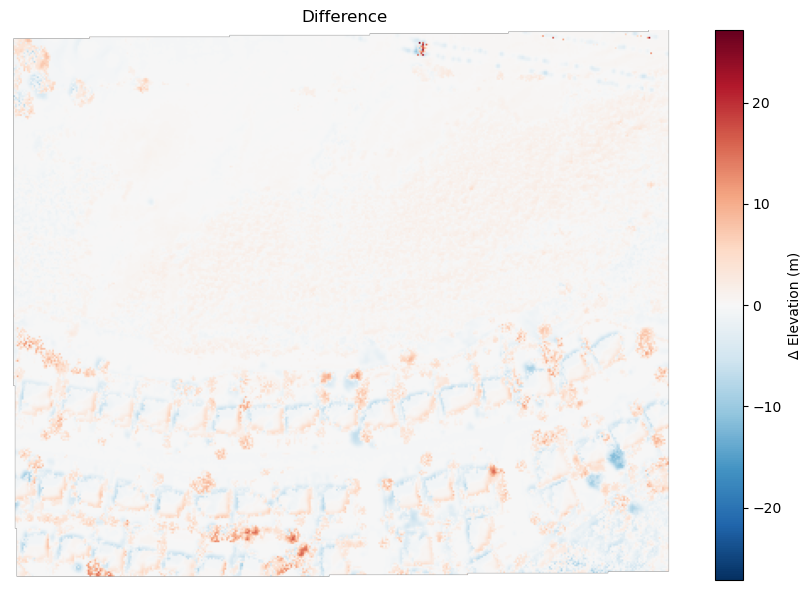

In [14]:
# Set units
dem1.set_units(vertical_unit=UNITS_COMPARE)
print("dem1 vertical_unit:", dem1.vertical_unit)
# dem2.set_units(vertical_unit=UNITS_REFERENCE)
# print("dem2 vertical_unit:", dem2.vertical_unit)

# Compute difference
output_dir = Path.joinpath(BASE_DATA_DIR,"dem_output")
pair = RasterPair(dem1, dem2)
if IN_COLAB:
    import os
    os.makedirs(output_dir, exist_ok=True)
    results = pair.compute_difference(
        skip_epoch=True,
        interpolation_method="bilinear",
        clip_to_overlap=True,
        output_path=str(output_dir / "difference.tif"),
        verbose=True
    )
else:
    results = pair.compute_difference(
        skip_epoch=True,
        interpolation_method="bilinear",
        clip_to_overlap=True,
        verbose=True
    )

# Plot
fig = pair.plot_difference()

<h2><a id="visualization"></a>4. Visualization and derived rasters</h2>

This section focuses on visualizing the results and creating derived topographic products like hillshades and slope maps, which are useful for interpreting the observed changes.

<h3><a id="plot-dems"></a>Plot the DEMs and derived products</h3>

/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


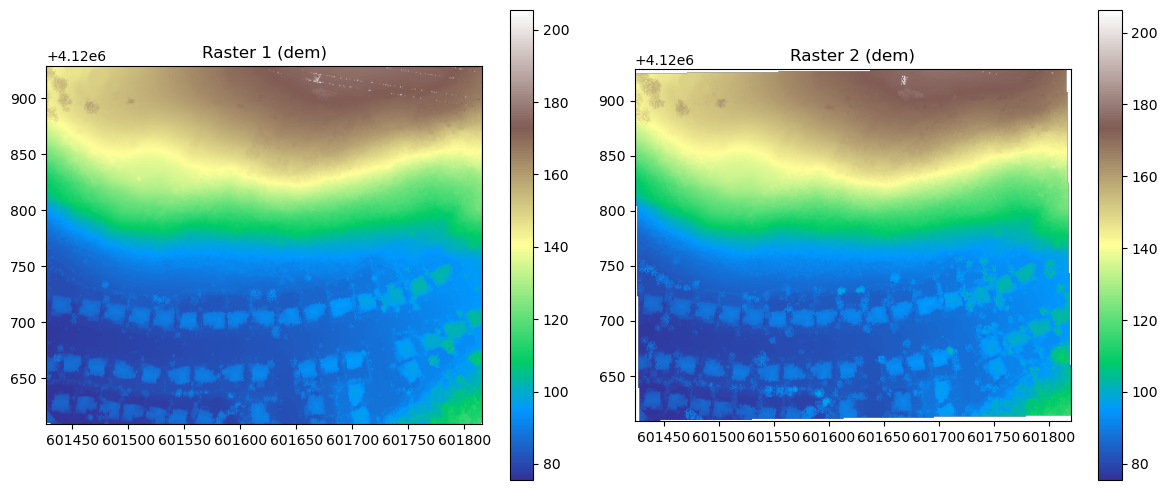

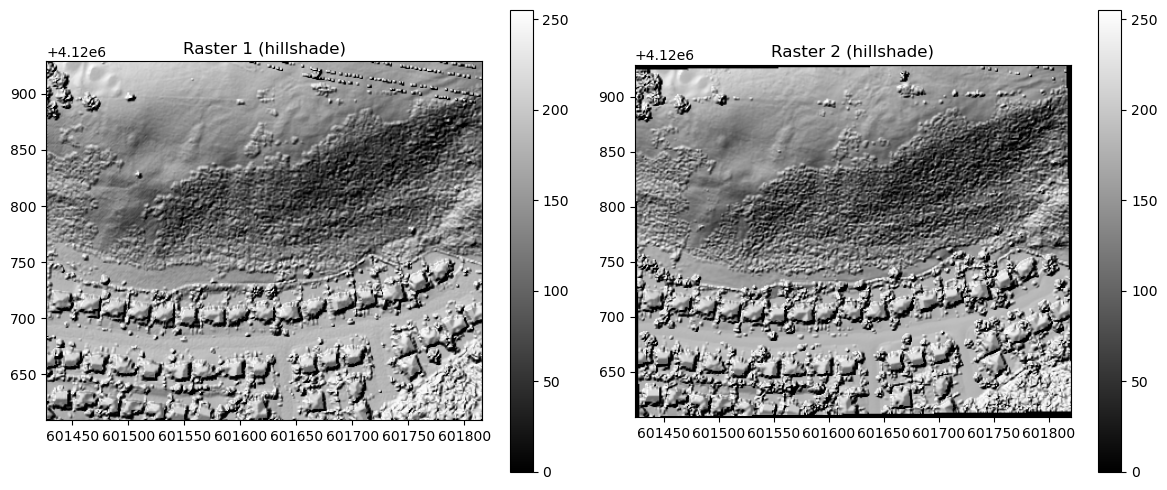

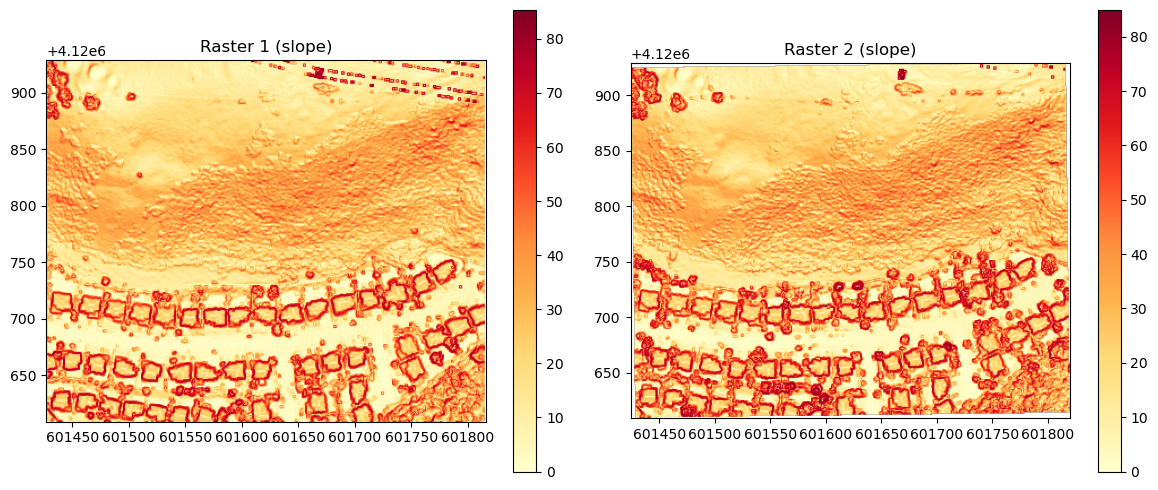

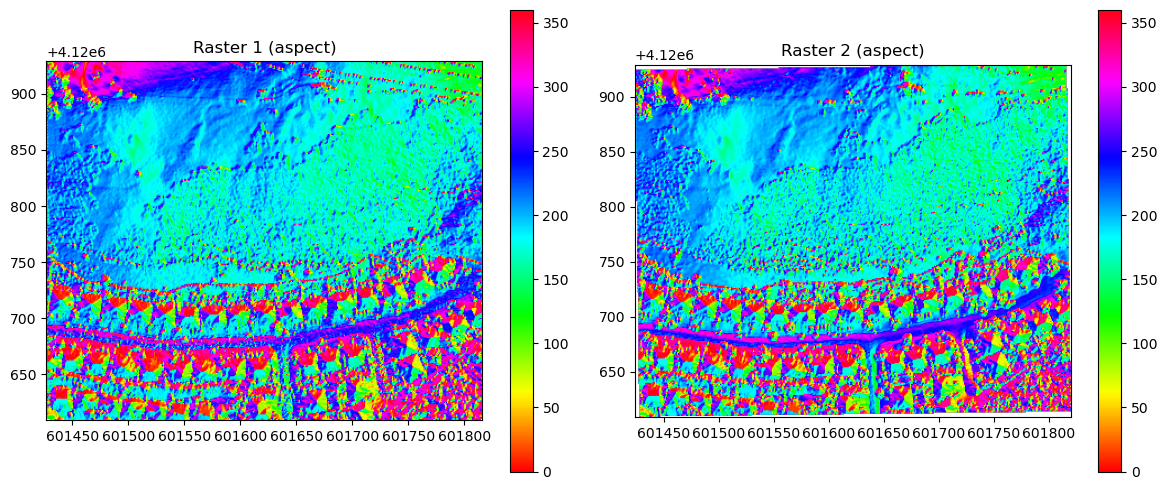

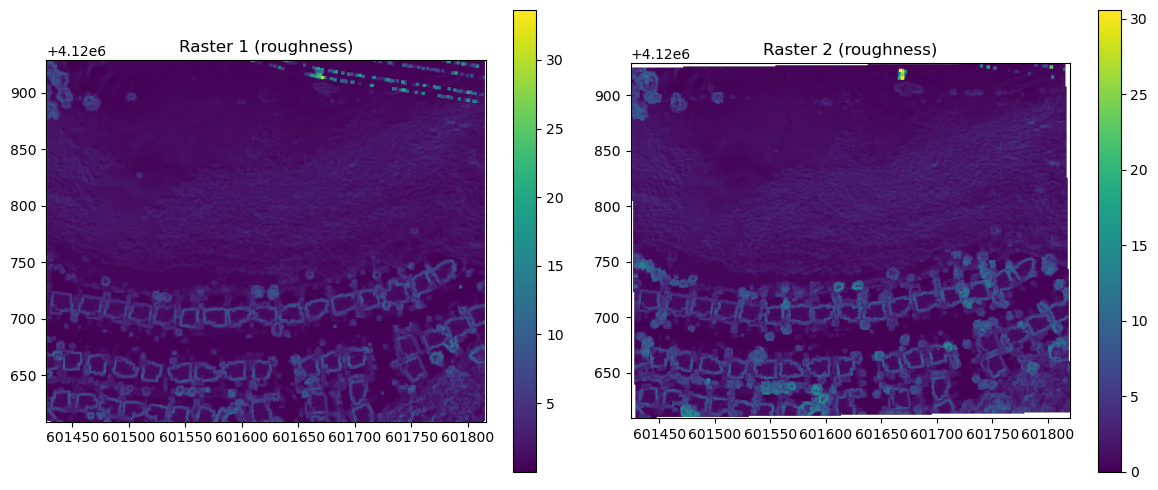

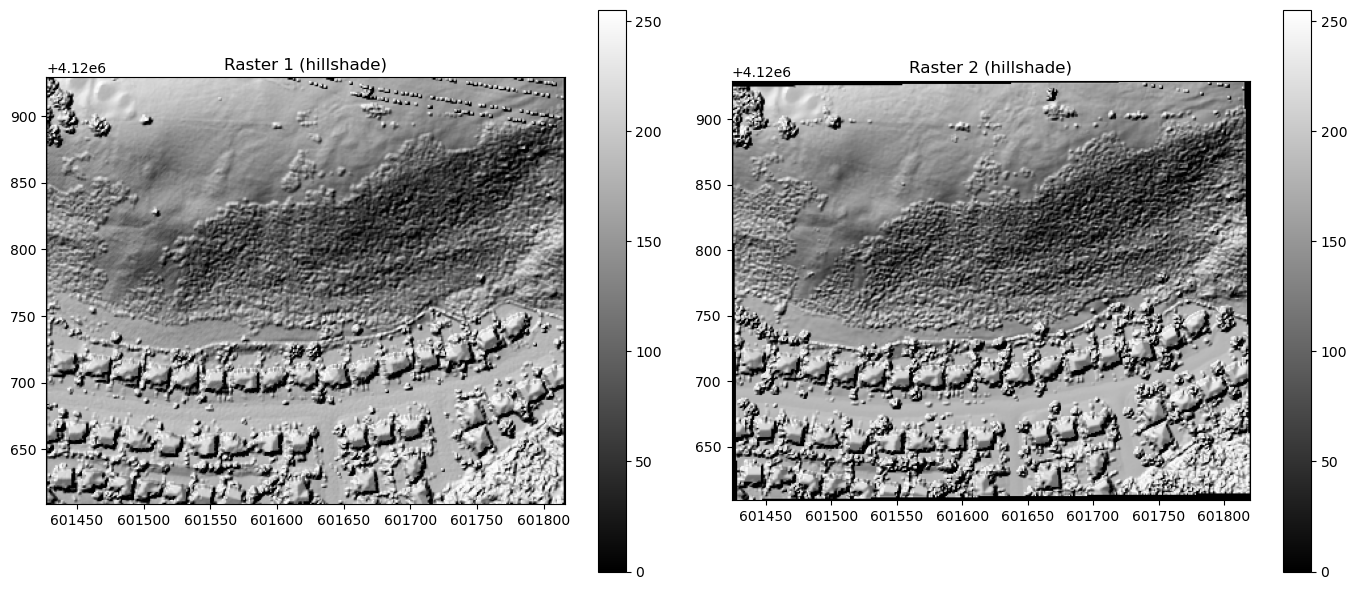

In [15]:
# Generate derivatives for both rasters
hillshade1, hillshade2 = pair.generate_derivative("hillshade")
slope1, slope2 = pair.generate_derivative("slope")
aspect1, aspect2 = pair.generate_derivative("aspect")
roughness1, roughness2 = pair.generate_derivative("roughness")

# Plot side-by-side with automatic derivative generation
fig, axes = pair.plot_pair(derivative='dem')        # Original DEMs
fig, axes = pair.plot_pair(derivative='hillshade')  # Hillshades
fig, axes = pair.plot_pair(derivative='slope')      # Slopes
fig, axes = pair.plot_pair(derivative='aspect')     # Aspects
fig, axes = pair.plot_pair(derivative='roughness')  # Roughness

# Customize hillshade parameters
fig, axes = pair.plot_pair(
    derivative='hillshade',
    azimuth=270,    # West-facing light
    altitude=30,    # Low sun angle
    figsize=(14, 6)
)

/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


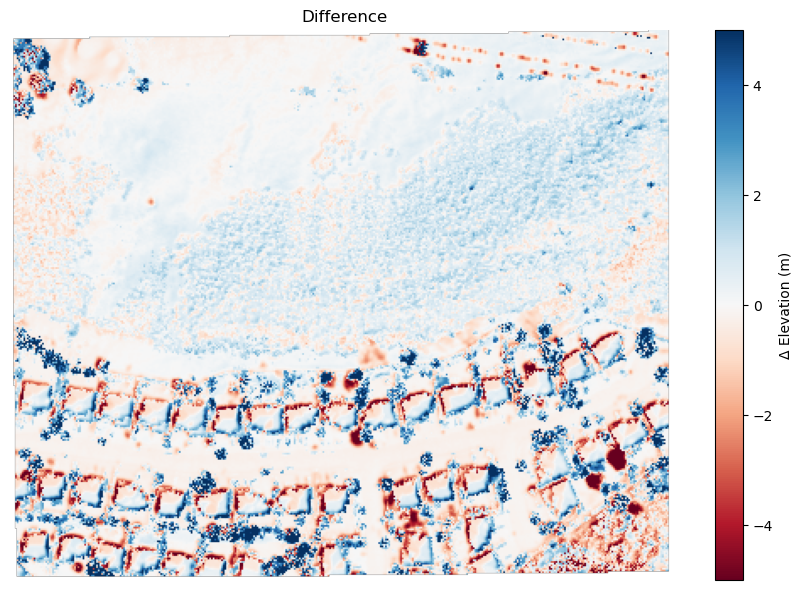

In [16]:
pair.plot_difference(
    vmax = 5,
    vmin = -5,
    cmap = "RdBu"
)

<h2><a id="error_analysis"></a>5. Error analysis</h2>

<h3><a id="theoretical_framework"></a>Theoretical framework</h3>

The error analysis framework implemented here follows the geostatistical approach described by [Rolstad et al., 2009](https://doi.org/10.3189/002214309789470950) and [Hugonnet et al., 2022](https://doi.org/10.1109/JSTARS.2022.3188922), adapted for lidar-derived topographic differencing.

Topographic differencing errors can be decomposed into three components:

1. **Systematic vertical bias** (μ): A constant offset between datasets, typically estimated as the median of stable-area differences to reduce outlier influence

2. **Spatially correlated random error**: Errors that exhibit spatial structure due to:
   - Point misclassification (meter to decameter scale)
   - Geometric distortion on slopes (decameter scale)
   - Horizontal alignment errors (hundred-meter scale)
   - Flight line striping (hundred-meter to kilometer scale)
   - Vertical datum inconsistencies (kilometer scale)

3. **Uncorrelated random noise** (nugget): High-frequency noise from sensor sensitivity, environmental conditions, and surface reflectivity ([Glennie, 2007](https://doi.org/10.1515/jag.2007.017))

The semivariogram γ(h) quantifies how the variance of differences increases with separation distance h (Matheron, 1965; [Webster & Oliver, 2007](https://doi.org/10.1002/9780470517277)):

$$\gamma(h) = \frac{1}{2N(h)} \sum_{i=1}^{N(h)} [\Delta_z(x_i) - \Delta_z(x_i + h)]^2$$

Key variogram parameters:
- **Nugget (c₀)**: Discontinuity at origin representing uncorrelated noise
- **Sill (c)**: Plateau value representing total variance
- **Range (a)**: Distance at which spatial correlation decays to negligible levels

For lidar data, **nested variograms** with multiple components capture error structures at different scales. Each spatial scale (short, medium, long range) contributes a portion of the total error variance.

<h3><a id="define_stable_areas"></a>Define stable areas</h3>


Stable areas are regions where **no topographic change is expected** between surveys. They serve as control zones for error calibration and the elevation differences within these areas represent pure error, allowing us to characterize the spatial structure of uncertainty.

<h4><a id="size_requirements"></a>Size requirements</h4>

The stable area must be large enough to reliably estimate the empirical variogram. Key constraints include (Journel & Huijbregts, 1978; [Oliver & Webster, 2015](https://doi.org/10.1007/978-3-319-15865-5)):

<h5><a id="min_pairs"></a>1. Minimum pairs per lag bin</h5>
Each lag bin in the variogram requires **at least 30 pairs**, with 50+ pairs recommended. Fewer than 20 pairs per bin produces unreliable estimates with high variance.

<h5><a id="var_coverage"></a>2. Variogram coverage rule</h5>
The variogram should span **less than half the domain size** to avoid pairing samples from opposite edges (Journel & Huijbregts, 1978). This means that if you expect correlation ranges up to 500 m, your stable area should have at least a 1 km extent in its longest dimension.

<h5><a id="corr_scales"></a>3. Capturing all correlation scales</h5> 
The largest correlation scale has the greatest impact on uncertainty estimates ([Rolstad et al., 2009](https://doi.org/10.3189/002214309789470950)). Typical lidar error correlation ranges span:

- **Short-range**: 10–100 m (point classification, geometric distortion)
- **Mid-range**: 100–1000 m (horizontal alignment, flight lines)
- **Long-range**: >1 km (vertical datum, geoid errors)

Your stable areas should extend far enough to capture all relevant scales.

<h4><a id="good_stable_area"></a>What makes a good stable area?</h4> 

**Ideal choices**:
- Roads and parking lots (paved, unvegetated)
- Bedrock outcrops (geologically stable)
- Flat, undisturbed terrain
- Areas with similar terrain properties (slope, roughness) to your areas of interest

**Areas to avoid**:
- Vegetation change zones (leaf-on vs. leaf-off)
- Construction or development areas
- Water bodies (variable water levels)
- Very steep slopes (higher geometric distortion)
- DEM boundary edges (edge effects)
- Areas with real expected change

<h4><a id="heteroscedasticity_consideration"></a>Heteroscedasticity consideration</h4>

Errors can vary with terrain properties. [Hugonnet et al., 2022](https://doi.org/10.1109/JSTARS.2022.3188922) explored how error variance changes with parameters such as slope and roughness. Ideally, stable areas should have similar terrain characteristics to your areas of interest, or you should account for this heteroscedasticity in the analysis. [xDEM](https://xdem.readthedocs.io/en/stable/uncertainty.html#heteroscedasticity) offers tools to model raster heteroscedasticity.



**Use the interactive map below to draw polygons over areas you consider stable.**

**Instructions:**
1. Use the polygon tool to draw areas of no expected change
2. Select "Stable" from the layer dropdown when drawing
3. Aim for areas totaling at least 1 km² if you expect long-range correlations
4. Run the cells below after drawing your polygons

In [17]:
diff = results.get("difference_raster")

In [18]:
out_folder_poly = Path.joinpath(BASE_DATA_DIR,"polygons/")
os.makedirs(out_folder_poly, exist_ok=True)


interactor = TopoMapInteractor(
    topo_diff_path=diff.filename,
    hillshade_path=hillshade1.filename,
    output_dir=out_folder_poly,
    overlay_dpi=600,
    overlay_vmin=-5,
    overlay_vmax=5,
)

interactor.map

/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
Overlay: shape=(320, 396), nodata=nan
Valid pixels: 121,836 / 126,720 (96.1%)
Color range: [-5.000, 5.000]
Data range: [-12.159, 27.162]
Saved overlay: test_data/quick_test/polygons/reference_diff-c9ee817d09cf4567a1b5497d415eca61.png
Generated data URL: 269670 chars (202236 bytes)
Map bounds (lat/lon): ((37.22647791004359, -121.85671864601122), (37.22931866462554, -121.85221191786302))
Map center: (37.22789828733457, -121.85446528193711)
Using overlay: test_data/quick_test/polygons/reference_diff-c9ee817d09cf4567a1b5497d415eca61.png


Map(center=[37.22789828733457, -121.85446528193711], controls=(ZoomControl(options=['position', 'zoom_in_text'…

In [19]:
interactor.stable_geoms

[<POLYGON ((601433.637 4120903.169, 601439.403 4120624.065, 601593.585 412062...>]

In [20]:
interactor.unstable_geoms

[<POLYGON ((601728.129 4120682.592, 601742.339 4120644.816, 601799.594 412067...>]

<h3><a id="descriptive_stats"></a>Descriptive statistics</h3>

Before fitting a variogram, it is essential to examine the statistical characteristics of the stable area(s). Descriptive statistics provide a first-order assessment of the differencing errors and help evaluate whether the data meet the assumptions required for geostatistical analysis.

**Key statistics to examine:**

- **Mean and Median**: The median of the elevation differences in stable areas estimates the systematic vertical bias between the two DEMs. A non-zero median indicates a consistent offset that should be removed before variogram analysis. The mean is more sensitive to outliers, so comparing mean and median helps identify skewness in the distribution.

- **Standard Deviation and Variance**: These quantify the overall spread of elevation differences. High variance may indicate significant error sources or residual real change in areas assumed to be stable.

- **Skewness and Kurtosis**: Departures from normality can signal issues. Positive skewness might indicate unremoved vegetation or construction, while heavy tails (high kurtosis) could reflect outliers from misclassification or edge effects.

- **Percentiles (0.5%, 99.5%)**: Examining extreme percentiles helps identify outliers that may need to be filtered before variogram estimation.

**Assessing stationarity across stable areas:**

A fundamental assumption in geostatistics is *stationarity* — that the mean and variance of the error field are constant across the study area, and that spatial covariance depends only on separation distance, not absolute location ([Webster & Oliver, 2007](https://doi.org/10.1002/9780470517277)). Examining the statistics of each stable area *separately* provides a practical check:

1. **Compare means/medians across areas**: Substantially different median values may indicate spatially varying bias (e.g., from flight line effects or tilted datums), violating the assumption that a single variogram model applies everywhere.

2. **Compare variances across areas**: If one stable area has much higher variance than another, the error characteristics may depend on location or terrain properties. This *heteroscedasticity* suggests that a single variogram may not adequately represent error structure across the entire scene ([Hugonnet et al., 2022](https://doi.org/10.1109/JSTARS.2022.3188922)).

3. **Look for systematic patterns**: If stable areas on one side of the scene consistently show positive differences while those on the other side show negative differences, a regional trend or tilt may be present that should be modeled separately.

The table and histogram below summarize the distribution of elevation differences in your stable area(s). If you have defined multiple stable polygons, compare their individual statistics to assess spatial consistency.

In [21]:
stable_polys, _ = interactor.export_geodataframes()

# one combined mask
rasterizer_stable = StableAreaRasterizer(interactor.topo_diff.path, stable_polys, nodata=-9999)
analyzer_stable = StableAreaAnalyzer(rasterizer_stable)

# Combined-area stats
df_all_stable_polys = analyzer_stable.stats_all(Path.joinpath(BASE_DATA_DIR,"polygons/combined_stable.tif"))

# Per-area stats
df_each_stable_poly = analyzer_stable.stats_each(Path.joinpath(BASE_DATA_DIR,"polygons/each_stable/"))


In [22]:
df_all_stable_polys

,mean,median,mode,std,variance,min,max,skewness,kurtosis,0.5_percentile,99.5_percentile
all_areas,0.26268,0.086349,-0.049469,1.407902,1.982187,-8.552452,16.823402,2.029521,15.687206,-4.657919,7.190244


In [23]:
df_each_stable_poly

,mean,median,mode,std,variance,min,max,skewness,kurtosis,0.5_percentile,99.5_percentile
area_id,,,,,,,,,,,
0,0.26268,0.086349,-0.049469,1.407902,1.982187,-8.552452,16.823402,2.029521,15.687206,-4.657919,7.190244


<h3><a id="estimate-error"></a>Estimate systematic error</h3>


Systematic error (vertical bias) represents a constant offset between the two DEMs that affects all elevation differences uniformly. This bias can arise from instrument calibration errors, incorrect atmospheric corrections, GNSS/IMU misalignments, or inconsistencies in vertical coordinate reference systems such as mismatched geoid models ([Glennie, 2007](https://doi.org/10.1515/jag.2007.017); [Habib et al., 2009](https://doi.org/10.14358/PERS.75.10.1159)). Geoid errors typically produce shifts of 10–20 cm, while confusion between ellipsoidal and orthometric heights can cause offsets of tens of meters.

**Why use the median?**

We estimate vertical bias as the **median** of elevation differences in stable areas rather than the mean. The median is more robust to outliers(isolated large values from real change, misclassification, or edge effects—ensuring the bias estimate reflects the typical offset rather than being skewed by anomalous values) (Brigham et al.)

**Interpreting the bias:**

- A non-zero median indicates systematic offset that should be removed before variogram analysis
- The bootstrap uncertainty quantifies confidence in the bias estimate
- After bias removal, the distribution should be approximately centered on zero

**Important considerations:**

- If you observe widespread real change (e.g., regional uplift from an earthquake or isostatic rebound), this signal will be absorbed into the bias estimate and must be accounted for separately
- For DSM differencing, vegetation changes (leaf-on vs. leaf-off) can bias the median; consider estimating bias from DTM results instead
- Very large biases (>1 m) may indicate datum errors that should be investigated before proceeding

In [24]:

# Load the stable area raster (this is the masked difference raster)
stable_area_path = Path.joinpath(BASE_DATA_DIR, "polygons/combined_stable.tif")
stable_area = Raster.from_file(stable_area_path)

# Get the median from the stable area
# Read the data directly with rasterio to get valid values

with rasterio.open(stable_area_path) as src:
    data = src.read(1)
    nodata = src.nodata
    # Mask nodata values
    if nodata is not None:
        valid_data = data[data != nodata]
    else:
        valid_data = data[np.isfinite(data)]
    
    diff_stable_median = np.median(valid_data)
    print(f"Median of stable area differences: {diff_stable_median:.4f} m")

# Set up paths and parameters
output_path = Path.joinpath(BASE_DATA_DIR, "polygons/combined_stable_bias_removed.tif")
unit = "m"
dem_resolution = 1.0

# Load raster data using RasterDataHandler
raster_data_handler = RasterDataHandler(stable_area_path, unit, dem_resolution)
raster_data_handler.load_raster()

# Get the data array
vert_diff_array = raster_data_handler.data_array

# Measure of vertical bias (median)
vertical_bias = np.median(vert_diff_array)
print(f"Vertical bias: {vertical_bias:.4f} m")

# Get uncertainty in the median value by bootstrap resampling
stats = StatisticalAnalysis(raster_data_handler)
median_uncertainty = stats.bootstrap_uncertainty_subsample(n_bootstrap=1000, subsample_proportion=0.1)
print(f"Median uncertainty (bootstrap): {median_uncertainty:.4f} m")

# Subtract the vertical bias from the stable area raster and save
raster_data_handler.subtract_value_from_raster(output_path, vertical_bias)
print(f"Saved bias-removed raster to: {output_path}")

# Create new RasterDataHandler for the modified raster
raster_bias_removed = RasterDataHandler(output_path, unit, dem_resolution)
raster_bias_removed.load_raster()

print(f"\nBias-removed stats:")
print(f"  Mean: {np.mean(raster_bias_removed.data_array):.4f} m")
print(f"  Median: {np.median(raster_bias_removed.data_array):.4f} m")
print(f"  Std: {np.std(raster_bias_removed.data_array):.4f} m")

Median of stable area differences: 0.0863 m
Vertical bias: 0.0863 m
Median uncertainty (bootstrap): 0.0075 m
Saved bias-removed raster to: test_data/quick_test/polygons/combined_stable_bias_removed.tif

Bias-removed stats:
  Mean: 0.1763 m
  Median: 0.0000 m
  Std: 1.4079 m


/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


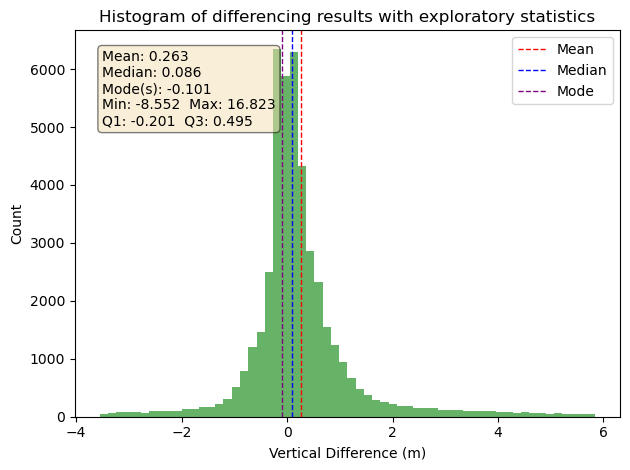

In [25]:
fig = stats.plot_data_stats()

<h3><a id="Variography"></a>Variography</h3>


Variography is the process of estimating and modeling the spatial covariance structure of your data. For topographic differencing, we analyze how elevation errors are correlated across space ([Webster & Oliver, 2007](https://doi.org/10.1002/9780470517277); [Oliver & Webster, 2014](https://doi.org/10.1016/j.catena.2013.09.006)).

<h4><a id="semivariogram"></a>The semivariogram</h4>

The **semivariogram** γ(h) measures the average squared difference between values separated by distance h (Matheron, 1965):

$$\gamma(h) = \frac{1}{2N(h)} \sum_{i=1}^{N(h)} [z(x_i) - z(x_i + h)]^2$$

At small distances, nearby points tend to have similar errors (low semivariance). As distance increases, the correlation breaks down and semivariance increases until it reaches a plateau (the sill).

The variogram has several key features:

1. **Nugget (c₀)**: The y-intercept, representing measurement noise and microscale variability below the sampling resolution

2. **Sill (c)**: The plateau value representing total variance. When the variogram reaches the sill, points are no longer spatially correlated.

3. **Range (a)**: The distance at which the sill is reached. Beyond this distance, errors are independent.

<h4><a id="nested_variogram"></a>Nested variograms for multi-scale error</h4> 

Lidar differencing errors operate at multiple scales simultaneously. A **nested variogram** captures this:

$$\gamma(h) = c_0 + \sum_{i=1}^{n} c_i \cdot \text{model}_i(h, a_i)$$

where each component (i) has its own partial sill (cᵢ) and range (aᵢ). For example:
- Component 1 (range ~30 m): Point classification errors
- Component 2 (range ~500 m): Flight line alignment errors
- Component 3 (range ~2 km): Geoid/datum inconsistencies

<h4><a id="model_selection"></a>Model Selection</h4>

We fit nested spherical models and select the best using:
- **AIC (Akaike Information Criterion)**: Balances fit quality vs. model complexity
- **Cross-validation**: Tests predictive performance on held-out data

The spherical model is commonly used because it has a finite range, provides smooth transitions, and handles nesting well ([Webster & Oliver, 2007](https://doi.org/10.1002/9780470517277)).

<h4><a id="sampling"></a>Sampling for computational efficiency</h4>

Computing all pairwise distances for a large raster is computationally prohibitive. We use:
- **Stratified random sampling**: Divide the raster into sub-grids and sample uniformly
- **Multiple realizations**: Repeat sampling ~30 times to estimate confidence bounds ([Ortiz & Deutsch, 2002](https://doi.org/10.1023/A:1014412218427))
- **Numba JIT compilation**: Accelerates the pairwise calculations

In [26]:
#Create variogram analysis instance based on modified raster
V = VariogramAnalysis(raster_bias_removed)

#Calculate a mean variogram with 75 bins from variograms made over 10 runs
V.calculate_mean_variogram_numba(area_side = 250, samples_per_area = 400, max_samples = 1000000000, bin_width = 30, max_n_bins = 3000, n_runs = 30, max_lag_multiplier = 0.5)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/src/topochange/variogram.py:1172: RuntimeWarning: Mean of empty slice
  mean_variogram = np.nanmean(vario_arr, axis=0)
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/src/topochange/variogram.py:1176: RuntimeWarning: Mean of empty slice
  mean_count = np.nanmean(count_arr, axis=0)
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [28]:
# Multi-model fitting, compare spherical, exponential, gaussian, matern
print("=" * 70)
print("MULTI-MODEL VARIOGRAM FITTING")
print("=" * 70)

# Fit all candidate models and select best by AIC
best_model = V.fit_best_model_auto(
    model_types=['spherical', 'exponential', 'gaussian', 'matern'],
    max_components=3,
    include_nugget=False,
    criterion='aic',
    compute_cv=True,
    n_bootstrap=500,
    seed=SEED,
)

print(f"\nBest model: {'+'.join(best_model.composite_model.component_names)}")
print(f"AIC: {best_model.aic:.2f}")
print(f"BIC: {best_model.bic:.2f}")
print(f"CV-RMSE: {best_model.cv_rmse:.4f}" if best_model.cv_rmse else "CV-RMSE: N/A")

# Print model parameters
print(f"\n{'─' * 40}")
print("Model Parameters:")
print(f"{'─' * 40}")
cm = best_model.composite_model
print(f"  Nugget: {cm.get_nugget():.6f}")
for i, name in enumerate(cm.component_names):
    comp_params = cm.get_component_params(i)
    param_names = cm.param_names
    # Each component has sill, range (and possibly extra params like nu for matern)
    print(f"\n  Component {i+1}: {name}")
    print(f"    Sill:  {comp_params[0]:.6f}")
    print(f"    Range: {comp_params[1]:.6f}")
    if len(comp_params) > 2:
        for j, val in enumerate(comp_params[2:], start=2):
            print(f"    Param {j}: {val:.6f}")
print(f"\n  Total sill: {cm.get_total_sill():.6f}" if cm.get_total_sill() is not None else "\n  Total sill: N/A (unbounded model)")

MULTI-MODEL VARIOGRAM FITTING


/Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/src/topochange/variogram.py:395: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(



Best model: exponential
AIC: 24.52
BIC: 25.12
CV-RMSE: 1.2341

────────────────────────────────────────
Model Parameters:
────────────────────────────────────────
  Nugget: 0.000000

  Component 1: exponential
    Sill:  4.509859
    Range: 176.714131

  Total sill: 4.509859


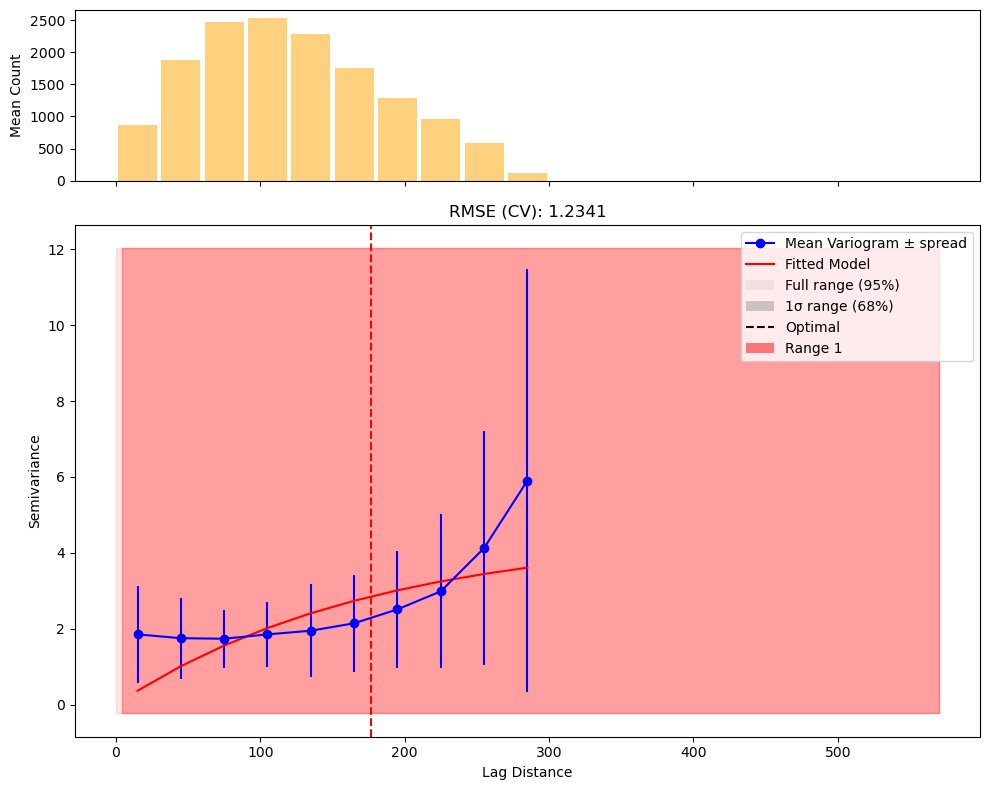

In [29]:
fig = V.plot_best_model()

<h3><a id="uncertainty_propagation"></a>Uncertainty propagation</h3>

Once we have a fitted variogram model, we can propagate uncertainty to any area of interest ([Rolstad et al., 2009](https://doi.org/10.3189/002214309789470950)). This is the key step that transforms error characterization into actionable uncertainty bounds.

For a spatially averaged elevation change over an area A, the regional variance σ²_A depends on the spatial covariance structure:

$$\sigma_A^2 = \frac{1}{A^2} \int_A \int_A [\sigma_{\Delta_z}^2 - \gamma(h)] \, dx \, dy$$

**Intuition**: If all points in your area are highly correlated (small area relative to the range), errors move together and uncertainty is high. If points are spread over a large area with mixed positive and negative errors that partially cancel, uncertainty decreases.

A crucial insight: **uncertainty decreases as the area of aggregation increases**, but at different rates depending on the variogram parameters:
- Features smaller than the correlation range: errors are correlated and don't cancel out (uncertainty ≈ √sill)
- Features much larger than the correlation range: errors average toward zero (uncertainty ≈ √(sill / n_effective))

With a nested variogram, each component contributes independently:

$$\sigma_{total}^2 = \sigma_{nugget}^2 + \sigma_{short}^2 + \sigma_{mid}^2 + \sigma_{long}^2$$

For irregularly shaped polygons, we use **Monte Carlo integration**: randomly sample N pairs of points within the polygon, compute covariances using the fitted variogram, and average to approximate the double integral (~10,000–25,000 pairs).

<h4><a id="features_of_interest"></a>Draw features of interest (unstable areas)</h4> 

Use the interactive map below to draw polygons around areas where you expect topographic change (e.g., landslides, construction sites, eroded channels, deposited sediment bars). The uncertainty will be calculated for each polygon.

In [30]:
interactor.map

Map(bottom=26067912.0, center=[37.2279023058015, -121.85447216033937], controls=(ZoomControl(options=['positio…

In [31]:
interactor.unstable_geoms

[<POLYGON ((601728.129 4120682.592, 601742.339 4120644.816, 601799.594 412067...>]

In [32]:
_, unstable_polys = interactor.export_geodataframes()

In [33]:
# Calculate uncertainty for each feature of interest
# Pass fitted_model so any variogram model type (spherical, matern, damped_hole_effect, etc.) is supported

uncertainties_per_feature = []

for i, poly in enumerate(unstable_polys['geometry']):
    print(f"\nProcessing polygon {i+1}/{len(unstable_polys)}...")

    estimator = RegionalUncertaintyEstimator(
        raster_data_handler=raster_bias_removed,
        variogram_analysis=V,
        area_of_interest=poly,
        fitted_model=V.fitted_model,
    )

    estimator.calc_total_uncertainty(n_pairs=25_000, seed=SEED)
    uncertainties_per_feature.append(estimator)

# Print detailed summary for first polygon
print("\n")
print(uncertainties_per_feature[0].summary())


Processing polygon 1/1...


REGIONAL UNCERTAINTY SUMMARY
Polygon area: 2325.58 m²
Total variance (σ²): 4.509859; min: 3.607887; max: 5.411831

Uncorrelated σ₀: 1.418901
Uncorrelated (polygon mean): 0.029423

POLYGON CORRELATED UNCERTAINTY:
  Total: 1.627749; min: 1.162043; max: 2.195333

POLYGON TOTAL UNCERTAINTY:
  Total: 1.628014; min: 1.162415; max: 2.195530

----------------------------------------------------------------------
RASTER CORRELATED UNCERTAINTY:
  Uncorrelated (raster mean): 0.006636
  Total: 1.447394; min: 1.131048; max: 1.731162

RASTER TOTAL UNCERTAINTY:
  Total: 1.447409; min: 1.131068; max: 1.731174


---

<h2><a id="references"></a>References</h2>

- Albino, F., Smets, B., d'Oreye, N. & Kervyn, F. (2015). High‐resolution TanDEM‐X DEM: An accurate method to estimate lava flow volumes at Nyamulagira Volcano (D.R. Congo). *Journal of Geophysical Research: Solid Earth*, 120, 4189–4207. [https://doi.org/10.1002/2015JB011988](https://doi.org/10.1002/2015JB011988)

- Anderson, S.W. (2019). Uncertainty in quantitative analyses of topographic change: error propagation and the role of thresholding. *Earth Surface Processes and Landforms*, 44, 1015–1033. [https://doi.org/10.1002/esp.4551](https://doi.org/10.1002/esp.4551)

- Besl, P.J. & McKay, N.D. (1992). Method for registration of 3-D shapes. *Sensor Fusion IV: Control Paradigms and Data Structures*, SPIE, 586–606. [https://doi.org/10.1117/12.57955](https://doi.org/10.1117/12.57955)

- Brasington, J. & Smart, R.M.A. (2003). Close range digital photogrammetric analysis of experimental drainage basin evolution. *Earth Surface Processes and Landforms*, 28, 231–247. [https://doi.org/10.1002/esp.480](https://doi.org/10.1002/esp.480)

- Brasington, J., Langham, J. & Rumsby, B. (2003). Methodological sensitivity of morphometric estimates of coarse fluvial sediment transport. *Geomorphology*, 53, 299–316. [https://doi.org/10.1016/S0169-555X(02)00320-3](https://doi.org/10.1016/S0169-555X(02)00320-3)

- Dehecq, A., Gardner, A.S., Alexandrov, O., McMichael, S., Hugonnet, R., Shean, D. & Marty, M. (2020). Automated Processing of Declassified KH-9 Hexagon Satellite Images for Global Elevation Change Analysis Since the 1970s. *Frontiers in Earth Science*, 8, 566802. [https://doi.org/10.3389/feart.2020.566802](https://doi.org/10.3389/feart.2020.566802)

- Glennie, C.L., Hinojosa‐Corona, A., Nissen, E., Kusari, A., Oskin, M.E., Arrowsmith, J.R. & Borsa, A. (2014). Optimization of legacy lidar data sets for measuring near‐field earthquake displacements. *Geophysical Research Letters*, 41, 3494–3501. [https://doi.org/10.1002/2014GL059919](https://doi.org/10.1002/2014GL059919)

- Glennie, C. (2007). Rigorous 3D error analysis of kinematic scanning LIDAR systems. *Journal of Applied Geodesy*, 1, 147–157. [https://doi.org/10.1515/jag.2007.017](https://doi.org/10.1515/jag.2007.017)

- Heritage, G.L., Milan, D.J., Large, A.R.G. & Fuller, I.C. (2009). Influence of survey strategy and interpolation model on DEM quality. *Geomorphology*, 112, 334–344. [https://doi.org/10.1016/j.geomorph.2009.06.024](https://doi.org/10.1016/j.geomorph.2009.06.024)

- Hugonnet, R., Brun, F., Berthier, E., Dehecq, A., Mannerfelt, E.S., Eckert, N. & Farinotti, D. (2022). Uncertainty analysis of digital elevation models by spatial inference from stable terrain. *IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing*, 15, 6456–6472. [https://doi.org/10.1109/JSTARS.2022.3188922](https://doi.org/10.1109/JSTARS.2022.3188922)

- Izumida, A., Uchiyama, S. & Sugai, T. (2017). Application of UAV-SfM photogrammetry and aerial lidar to a disastrous flood: repeated topographic measurement of a midstream 2 river during a recovery. *Natural Hazards and Earth System Sciences*, 17, 1505–1519. [https://doi.org/10.5194/nhess-17-1505-2017](https://doi.org/10.5194/nhess-17-1505-2017)

- Journel, A.G. & Huijbregts, C.J. (1978). *Mining Geostatistics*. Academic Press.

- Lane, S.N., Westaway, R.M. & Hicks, D.M. (2003). Estimation of erosion and deposition volumes in a large, gravel‐bed, braided river using synoptic remote sensing. *Earth Surface Processes and Landforms*, 28, 249–271. [https://doi.org/10.1002/esp.483](https://doi.org/10.1002/esp.483)

- Langridge, R.M., Ries, W.F., Farrier, T., Barth, N.C., Khajavi, N. & De Pascale, G.P. (2014). Developing sub 5-m lidar DEMs for forested sections of the Alpine and Hope faults, South Island, New Zealand. *Geomorphology*, 226, 226–240. [https://doi.org/10.1016/j.geomorph.2014.08.007](https://doi.org/10.1016/j.geomorph.2014.08.007)

- Lucieer, A., de Jong, S.M. & Turner, D. (2014). Mapping landslide displacements using Structure from Motion (SfM) and image correlation of multi-temporal UAV photography. *Progress in Physical Geography*, 38, 97–116. [https://doi.org/10.1177/0309133313515293](https://doi.org/10.1177/0309133313515293)

- Matheron, G. (1965). *Les variables régionalisées et leur estimation*. Masson, Paris.

- Oliver, M.A. & Webster, R. (2014). A tutorial guide to geostatistics: Computing and modelling variograms and kriging. *Catena*, 113, 56–69. [https://doi.org/10.1016/j.catena.2013.09.006](https://doi.org/10.1016/j.catena.2013.09.006)

- Oliver, M.A. & Webster, R. (2015). *Basic Steps in Geostatistics: The Variogram and Kriging*. Springer. [https://doi.org/10.1007/978-3-319-15865-5](https://doi.org/10.1007/978-3-319-15865-5)

- Ortiz, J.M. & Deutsch, C.V. (2002). Calculation of uncertainty in the variogram. *Mathematical Geology*, 34(2), 169–183. [https://doi.org/10.1023/A:1014412218427](https://doi.org/10.1023/A:1014412218427)

- Passalacqua, P., Belmont, P., Staley, D.M. et al. (2015). Analyzing high resolution topography for advancing the understanding of mass and energy transfer through landscapes: A review. *Earth-Science Reviews*, 148, 174–193. [https://doi.org/10.1016/j.earscirev.2015.05.012](https://doi.org/10.1016/j.earscirev.2015.05.012)

- Rolstad, C., Haug, T. & Denby, B. (2009). Spatially integrated geodetic glacier mass balance and its uncertainty based on geostatistical analysis: application to the western Svartisen ice cap, Norway. *Journal of Glaciology*, 55(192), 666–680. [https://doi.org/10.3189/002214309789470950](https://doi.org/10.3189/002214309789470950)

- Schaffrath, K.R., Belmont, P. & Wheaton, J.M. (2015). Landscape-scale geomorphic change detection: Quantifying spatially variable uncertainty and circumventing legacy data issues. *Geomorphology*, 250, 334–348. [https://doi.org/10.1016/j.geomorph.2015.09.020](https://doi.org/10.1016/j.geomorph.2015.09.020)

- Scott, C., Arrowsmith, J.R., Nissen, E., Lajoie, L., Maruyama, T. & Chiba, T. (2018). The M7 2016 Kumamoto, Japan, Earthquake: 3-D Deformation Along the Fault and Within the Damage Zone Constrained From Differential Lidar Topography. *Journal of Geophysical Research: Solid Earth*, 123, 6138–6155. [https://doi.org/10.1029/2018JB015581](https://doi.org/10.1029/2018JB015581)

- Scott, C., Phan, M., Nandigam, V., Crosby, C. & Arrowsmith, J.R. (2021). Measuring change at Earth's surface: On-demand vertical and three-dimensional topographic differencing implemented in OpenTopography. *Geosphere*, 17, 1318–1332. [https://doi.org/10.1130/GES02259.1](https://doi.org/10.1130/GES02259.1)

- Webster, R. & Oliver, M.A. (2007). *Geostatistics for Environmental Scientists*, 2nd ed. John Wiley & Sons. [https://doi.org/10.1002/9780470517277](https://doi.org/10.1002/9780470517277)

- Wheaton, J.M., Brasington, J., Darby, S.E. & Sear, D.A. (2010). Accounting for uncertainty in DEMs from repeat topographic surveys: improved sediment budgets. *Earth Surface Processes and Landforms*, 35, 136–156. [https://doi.org/10.1002/esp.1886](https://doi.org/10.1002/esp.1886)

